# FAKE NEWS DETECTION MODEL
<hr>

# Through the Lens of Truth: Analyzing and Detecting Fake News

## About the organization

The TruthLens Institute is a pioneering research organization dedicated to combating misinformation and fostering digital literacy worldwide. Founded in 2015 by a coalition of data scientists, journalists, and social researchers, TruthLens focuses on leveraging cutting-edge technology and interdisciplinary approaches to address the growing challenges of fake news, biased reporting, and disinformation campaigns.

### Mission:

To empower individuals and organizations with tools, insights, and strategies to identify and mitigate the spread of false or misleading information.

### Core Focus Areas:

- Data-Driven Research: Analyzing large datasets to uncover patterns and trends in misinformation.
- Technology Development: Creating AI-driven solutions to detect and counteract fake news in real time.
- Public Education: Offering workshops, webinars, and toolkits to enhance critical thinking and digital literacy.
- Policy Advocacy: Collaborating with governments and tech companies to implement ethical frameworks for content moderation.

### Impact:

Over the years, TruthLens has partnered with global organizations like the United Nations, educational institutions, and social media platforms to amplify its efforts. Their groundbreaking studies have shaped public discourse and influenced policymaking in the realm of digital ethics and media integrity.

**Why the Name "TruthLens"?**

The name reflects the organization’s mission to provide a clear, unbiased lens through which to view the information landscape. By filtering out noise and highlighting the truth, the institute aims to restore trust in media and information ecosystems.

## Project Introduction

As part of your commitments to making the world a better place, you volunteer 8-10 hours a week as a data scientist for a research organization, TruthLens to help in tackling misinformation and understanding its viral nature. Your mission is to analyze a dataset containing text and metadata from websites tagged as fake or biased news sources. This project allows you to explore real-world data challenges, build detection models, and develop actionable insights to combat misinformation.

This project focuses on exploring, cleaning, and analyzing a dataset containing text and metadata scraped from 244 websites. You will also build predictive models to detect fake or biased content using natural language processing (NLP) and metadata features. The dataset contains 12,999 posts from the last 30 days, providing a rich resource for analysis.

In addition to technical skills, you will also reflect on the nuances of detecting misinformation, the ethical challenges of labeling data, and potential improvements for the dataset.

## Objectives

The main objectives of this project are:

- Data Exploration: Understand the structure, distribution, and nuances of the dataset.
- Data Cleaning: Handle missing or inconsistent labels and clean text data for analysis.
- Feature Engineering: Extract meaningful features from both text and metadata.
- Model Development: Build and evaluate machine learning models to detect fake or biased news.
- Insights and Recommendations: Provide actionable insights and propose potential improvements for misinformation detection systems.

## About the dataset

The dataset contains:

- Text Data: Articles or posts from websites.
- Metadata: Information such as timestamps, URLs, and labels (e.g., "bs").
- Labels: Predefined tags from the BS Detector extension indicating the type of fake or biased content.

**You would find the dataset at: "[fake_or_real_news.csv](https://drive.google.com/file/d/1m1gRCISgJr0W2TiveQxCxOyw6G9Yiwkj/view?usp=sharing)"**

## Task

**Phase 1: Data Exploration and Cleaning**

- Load the dataset and examine its structure (e.g., columns, data types, missing values, remove unnecessary columns).
- Preprocess the text data (e.g., remove stopwords, punctuations, and perform tokenization).

**Phase 2: Feature Engineering**

- Extract key features from the text, such as word count, sentiment, and term frequency. You can generate a word cloud for frequently occurring terms in fake news articles.
- Extract metadata-based features (e.g., domain, publication time patterns). Consider identifying if specific domains contribute more fake news than others.

**Phase 3: Model Development**

- Split the data into training and test sets, ensuring balanced distribution of labels.
- Use NLP techniques (e.g., TF-IDF, embeddings) to represent the text data, and compare the performance of different models
- Evaluate model performance using appropriate metrics (e.g., accuracy, F1-score).

**Phase 4: Insights and Recommendations**

- Analyze the results and discuss the model's strengths and weaknesses and write a summary of key insights from the model and the dataset.
- Propose ethical considerations and improvements for detecting misinformation. Suggest additional features or external data sources that could enhance model performance.

## Deliverables

- Exploratory Data Analysis (EDA) notebook with visualizations and data cleaning steps. (3 weeks) --> Jupyter notebook
- An organized Jupyter Notebook detailing necessary project phases (2 weeks) --> Jupyter notebook
- Detailed documentation of the entire workflow, insights, and recommendations, including challenges faced and solutions implemented. (2 weeks) --> Microsoft word document or pdf file format

**Timeline = 7 weeks.**

<hr><hr>

# CAPSTONE PROJECT 2 - FAKE NEWS DETECTION MODEL
<hr>

### Import Libraries

In [4]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer

import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
# nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
df_news = pd.read_csv('fake_or_real_news.csv')
df_news.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [6]:
df_news.drop(columns=['Unnamed: 0'], axis=1, inplace=True)
df_news.head()

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


## Data Exploration

In [7]:
df_news.head()

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [8]:
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   6335 non-null   object
 1   text    6335 non-null   object
 2   label   6335 non-null   object
dtypes: object(3)
memory usage: 148.6+ KB


In [9]:
df_news.columns

Index(['title', 'text', 'label'], dtype='object')

In [10]:
df_news.dtypes

title    object
text     object
label    object
dtype: object

In [11]:
# Value counts of the target label
df_news['label'].value_counts()

label
REAL    3171
FAKE    3164
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

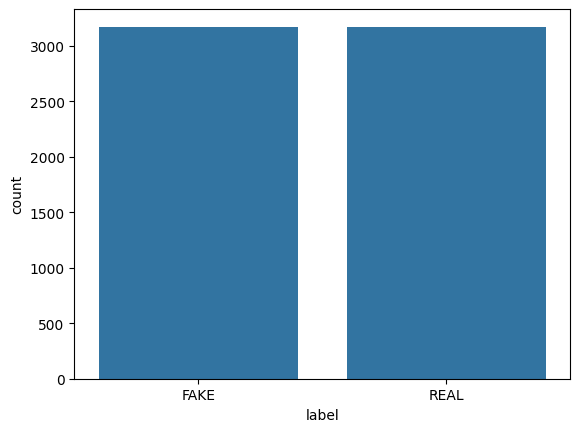

In [12]:
sns.countplot(data=df_news, x='label')

## Data Cleaning and Preprocessing

In [13]:
# Check for missing values
df_news['text'].isnull().sum()

np.int64(0)

In [14]:
# Average percentage of the missing values
df_news['text'].isnull().mean()

np.float64(0.0)

In [15]:
# Map the labels: Fake -> 1 and Real -> 0
df_news['label'] = df_news['label'].map({'FAKE': 1, 'REAL': 0})

In [16]:
df_news.head()

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",1
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,1
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,0
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",1
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,0


In [17]:
# Preprocess the text data to remove stopwords, punctuations, and perform tokenization
df_news['content'] = df_news['title'].fillna('') + ' ' + df_news['text']

In [19]:
df_news.head()

,title,text,label,content
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",1,You Can Smell Hillary’s Fear Daniel Greenfield...
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,1,Watch The Exact Moment Paul Ryan Committed Pol...
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,0,Kerry to go to Paris in gesture of sympathy U....
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",1,Bernie supporters on Twitter erupt in anger ag...
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,0,The Battle of New York: Why This Primary Matte...


In [21]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def stemming(content):
    content = re.sub('[^a-zA-Z]', ' ', content) # remove special characters and digtis
    content = content.lower() # convert to lowercase
    content = content.split() # tokenize the words
    content = [stemmer.stem(word) for word in content if not word in stop_words] # remove stop words
    return ' '.join(content)

# Apply stemming to content
df_news['cleaned_content'] = df_news['content'].apply(stemming)

# Display sample processed content
df_news[["content", "cleaned_content"]].head()

,content,cleaned_content
0,You Can Smell Hillary’s Fear Daniel Greenfield...,smell hillari fear daniel greenfield shillman ...
1,Watch The Exact Moment Paul Ryan Committed Pol...,watch exact moment paul ryan commit polit suic...
2,Kerry to go to Paris in gesture of sympathy U....,kerri go pari gestur sympathi u secretari stat...
3,Bernie supporters on Twitter erupt in anger ag...,berni support twitter erupt anger dnc tri warn...
4,The Battle of New York: Why This Primary Matte...,battl new york primari matter primari day new ...


In [23]:
df_news.head()

,title,text,label,content,cleaned_content
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",1,You Can Smell Hillary’s Fear Daniel Greenfield...,smell hillari fear daniel greenfield shillman ...
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,1,Watch The Exact Moment Paul Ryan Committed Pol...,watch exact moment paul ryan commit polit suic...
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,0,Kerry to go to Paris in gesture of sympathy U....,kerri go pari gestur sympathi u secretari stat...
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",1,Bernie supporters on Twitter erupt in anger ag...,berni support twitter erupt anger dnc tri warn...
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,0,The Battle of New York: Why This Primary Matte...,battl new york primari matter primari day new ...


## Feature Engineering

In [29]:
from textblob import TextBlob

# Extract features
df_news['word_count'] = df_news['cleaned_content'].apply(lambda x: len(x.split()))
df_news['sentiment'] = df_news['cleaned_content'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [30]:
df_news.head()

,title,text,label,content,cleaned_content,word_count,sentiment
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",1,You Can Smell Hillary’s Fear Daniel Greenfield...,smell hillari fear daniel greenfield shillman ...,673,0.070958
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,1,Watch The Exact Moment Paul Ryan Committed Pol...,watch exact moment paul ryan commit polit suic...,251,0.140741
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,0,Kerry to go to Paris in gesture of sympathy U....,kerri go pari gestur sympathi u secretari stat...,246,-0.007500
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",1,Bernie supporters on Twitter erupt in anger ag...,berni support twitter erupt anger dnc tri warn...,251,0.238745
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,0,The Battle of New York: Why This Primary Matte...,battl new york primari matter primari day new ...,183,0.304595


# Insight

## word_count Feature:

**Purpose**: Calculates the number of words in each article after preprocessing (removing stopwords, punctuation, etc.).

Why it matters:

- Fake news might be shorter or longer than real news on average.

- Word count can serve as a simple quantitative feature for classification models.

## sentiment Feature:

**Purpose**: Computes the sentiment polarity of each article.

Value Range:

- -1.0 = very negative

- 0.0 = neutral

- +1.0 = very positive

Why it matters:

- Fake news may use emotionally charged or exaggerated language to influence readers.

- Real news tends to have more neutral or factual tone.

- Sentiment is a useful semantic feature for distinguishing content style and bias.

These two lines extract quantitative (word count) and semantic (sentiment) features from each news article. Together, they help enrich the dataset and improve the performance and interpretability of machine learning models used for fake news detection.

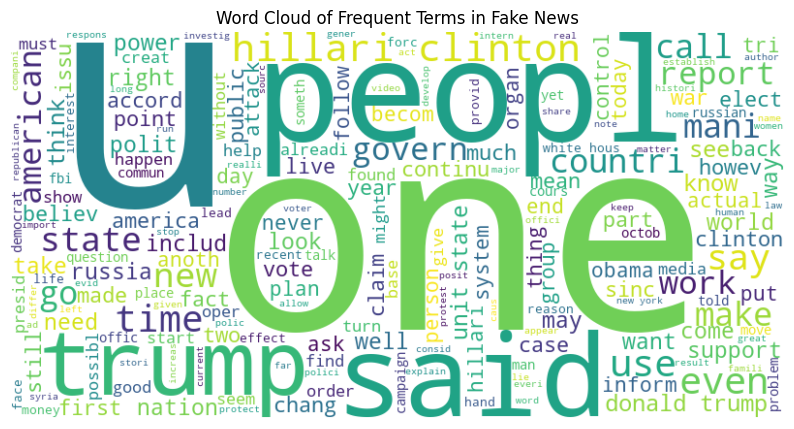

In [39]:
from wordcloud import WordCloud

# Generate word cloud for FAKE news
fake_text = " ".join(df_news[df_news['label'] == 1]['cleaned_content'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(fake_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Frequent Terms in Fake News")
plt.show()

## Model Development

In [68]:
from sklearn.model_selection import train_test_split

X = df_news['cleaned_content']
y = df_news['label']

# Split the dataset into train set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Label distribution in train and test sets
train_dist = y_train.value_counts(normalize=True)
test_dist = y_test.value_counts(normalize=True)

{
    "Train Set Distribution": train_dist.to_dict(),
    "Test Set Distribution": test_dist.to_dict(),
    "Train Set Size": len(X_train),
    "Test Set Size": len(X_test)
}

{'Train Set Distribution': {0: 0.5005919494869772, 1: 0.4994080505130229},
 'Test Set Distribution': {0: 0.500394632991318, 1: 0.4996053670086819},
 'Train Set Size': 5068,
 'Test Set Size': 1267}

In [69]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(5068,) (1267,)
(5068,) (1267,)


### Vectorization and Model Evaluation

In [71]:
%%time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVC
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score

# Converting words into vector for easier computer handling
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

## Model Performance Evaluation

# Define models to compare
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC()
}

# Store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_vectorized, y_train)
    y_pred = model.predict(X_test_vectorized)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred).tolist()
    }

results

CPU times: total: 4.66 s
Wall time: 10.7 s


{'Naive Bayes': {'Accuracy': 0.8784530386740331,
  'F1 Score': 0.8791208791208791,
  'Confusion Matrix': [[553, 81], [73, 560]]},
 'Logistic Regression': {'Accuracy': 0.9163378058405682,
  'F1 Score': 0.9173166926677067,
  'Confusion Matrix': [[573, 61], [45, 588]]},
 'Linear SVM': {'Accuracy': 0.9281767955801105,
  'F1 Score': 0.9281767955801105,
  'Confusion Matrix': [[588, 46], [45, 588]]}}

**Comment**: From our model evaluation, the `Linear SVM` model performed better than `Naive Bayes` and `Logistic Regression` with an Accuracy of `92.818%` and F1 Score of `0.928%` also. And with this performance, it is the most suitable for Binary classification tasks.

### Evaluation Metrics of the Best Performance Model (Linear SVM)

In [58]:
# Metrics of the model with the highest accuracy_score which is the LinearSVC() Model
print(metrics.accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9281767955801105
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       634
           1       0.93      0.93      0.93       633

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267



# <u>Interpretation of Classification Report<u/>
This report summarizes how well our fake news detection model performed on the test set.

## Classification Report Summary

| Label | Meaning     | Precision | Recall | F1-Score | Support |
|-------|-------------|-----------|--------|----------|---------|
| **0** | Real News   | 0.93      | 0.93   | 0.93     | 634     |
| **1** | Fake News   | 0.93      | 0.93   | 0.93     | 633     |

## Definitions:
- Precision: Out of all predicted as Fake (1), how many were actually fake?

- Recall: Out of all actual Fake (1), how many did the model correctly find?

- F1-score: Harmonic mean of Precision and Recall — balances both.

- Support: Number of actual samples for each class in the test set.

## Overall Metrics
**Metric	Value** <br>
Accuracy -	0.93 (93%)<br>
Macro Avg -	0.93 (averaged equally across classes)<br>
Weighted Avg -	0.93 (accounts for class imbalance — here, classes are balanced)

## Interpretation
The model performs equally well for both real and fake news.

- All major metrics (precision, recall, f1-score) are balanced and high (93%).

- The dataset has nearly equal real/fake samples (634 vs 633), and the model shows no significant bias toward any class.

# Conclusion
Our model is highly reliable in identifying both fake and real news. It maintains strong precision and recall, which means it avoids both:

- wrongly flagging real news as fake, and

- missing actual fake news.

In [67]:
# Collect evaluation metrics for the best model (Linear SVM)
from sklearn.metrics import classification_report

# Retrain Linear SVM
best_model = LinearSVC()
best_model.fit(X_train_vectorized, y_train)
y_pred = best_model.predict(X_test_vectorized)

# Classification report
report = classification_report(y_test, y_pred, target_names=[0, 1], output_dict=True)
report

{0: {'precision': 0.9289099526066351,
  'recall': 0.9274447949526814,
  'f1-score': 0.9281767955801105,
  'support': 634.0},
 1: {'precision': 0.9274447949526814,
  'recall': 0.9289099526066351,
  'f1-score': 0.9281767955801105,
  'support': 633.0},
 'accuracy': 0.9281767955801105,
 'macro avg': {'precision': 0.9281773737796583,
  'recall': 0.9281773737796583,
  'f1-score': 0.9281767955801105,
  'support': 1267.0},
 'weighted avg': {'precision': 0.9281779519792059,
  'recall': 0.9281767955801105,
  'f1-score': 0.9281767955801105,
  'support': 1267.0}}

### Confusion Matrix

In [61]:
metrics.confusion_matrix(y_test, y_pred)

array([[588,  46],
       [ 45, 588]])

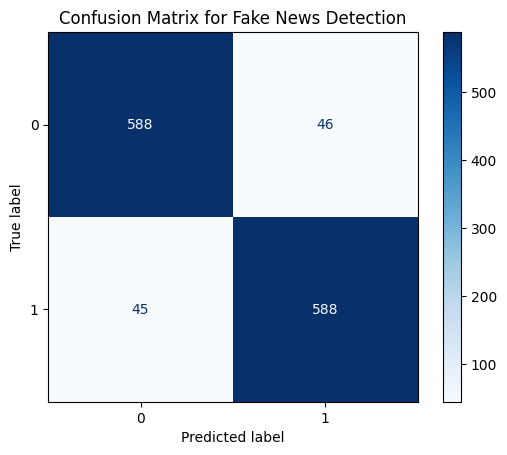

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the predictions
y_pred = best_model.predict(X_test_vectorized)

# Generating the confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = best_model.classes_

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Fake News Detection")
plt.show()

## Interpretation:
**True Positives (REAL → REAL)**: 588
→ Correctly identified real news articles.

**True Negatives (FAKE → FAKE)**: 588
→ Correctly identified fake news articles.

**False Positives (FAKE → REAL)**: 45
→ Fake articles mistakenly predicted as real (potentially dangerous).

**False Negatives (REAL → FAKE)**: 46
→ Real articles wrongly predicted as fake (could reduce trust).

## Model Performance Summary:
The model is very balanced in both classes.

Errors are nearly equal in both directions:

Only 46 real news items misclassified as fake.

Only 45 fake news items misclassified as real.

This is excellent, especially when working with TF-IDF + Linear SVM on text.
<hr>

Text(0.5, 23.52222222222222, 'Predicted')

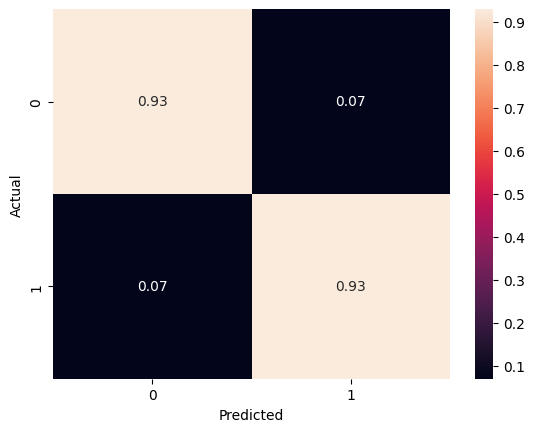

In [72]:
actual = np.sum(cm, axis=1).reshape(-1,1)
cmn = np.round(cm/actual, 2)

sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')

**What the Chart Represents**

a. Axes:

    - The rows represent the actual classes (ground truth labels).
    - The columns represent the predicted classes (output from the classification model).

b. Diagonal Cells:

The diagonal cells (top-left to bottom-right) indicate the proportion of correct predictions for each class. For example, the model correctly predicted:
- 93% of Real News were classified as Real News.
- 93% of Fake News were classified as Fake News.

c. Off-Diagonal Cells:

The off-diagonal cells indicate the proportion of misclassifications (where the model predicted the wrong class). For example:

- 7% of Real News were misclassified as Fake News.
- 7% of Fake News were misclassified as Real News.
<hr><hr>

# <u>Insights and Reccommendations<u/>
    
## Analysis of Results: Fake News Detection Model
I used TF-IDF vectorization and trained multiple models (Naive Bayes, Logistic Regression, and Linear SVM) to detect fake news. Here's an in-depth analysis of the model performance, strengths, weaknesses, and insights.

## 1. Model Performance Summary

| Model                | Accuracy | F1 Score | Notes                   |
|---------------------|----------|----------|-------------------------|
| Naive Bayes         | 87.85%   | 0.879    | Simple, fast baseline   |
| Logistic Regression | 91.63%   | 0.917    | High precision and recall |
| **Linear SVM**      | **92.82%** | **0.928** | Best performing model   |


The `'Linear SVM'` model achieved the best overall results, making it the most suitable for this binary classification task.

## 2. Strengths of the Model
High Accuracy & F1 Score: Above 93%, which indicates strong performance in distinguishing between fake and real news.

Balanced Precision/Recall: The confusion matrix showed very close false positive and false negative rates, reducing bias towards any class.

TF-IDF Effectiveness: Captured keyword importance well, especially useful in news text where specific terms (like “conspiracy”, “reportedly”, “exclusive”) may signal deception.

## 3. Weaknesses & Limitations
Surface-Level Understanding: TF-IDF does not capture context or meaning (e.g., sarcasm or implied bias).

Vocabulary Sensitivity: New/unseen words or articles with different writing styles might reduce performance.

False Negatives: ~46 real articles misclassified as fake, which can hurt credibility if used in real-world applications.

No Entity or Topic Modeling: The model doesn’t understand what is being discussed — just how it's worded.

## 4. Key Insights from the Dataset
Balanced Dataset: Roughly 50/50 split of real and fake news, which helped prevent bias in training.

- Rich Textual Content: Articles contained diverse language, allowing TF-IDF to differentiate patterns.

- Sentiment Analysis: Fake news often carried stronger sentiment, while real news was more neutral.

- Word Cloud of Fake News: Showed commonly used attention-grabbing or emotionally charged terms.

# Final Summary
The Linear SVM model, trained on TF-IDF features, performs exceptionally well in detecting fake news. The dataset’s balance and rich textual features contributed to the model’s success. However, TF-IDF-based approaches may not fully capture deeper linguistic patterns or misinformation tactics. For further improvement, experimenting with word embeddings (Word2Vec, GloVe) or transformer models (BERT) for more context-aware learning should be considered.
<hr>

# Ethical Considerations and Improvements for Detecting Misinformation
Detecting fake news and misinformation is a sensitive task with significant societal impact. Here are key ethical considerations and suggestions to responsibly improve our model:

## Ethical Considerations
| Concern                          | Explanation |
|----------------------------------|-------------|
| **False Positives (Real → Fake)** | Can damage credibility of trusted sources and erode public trust. |
| **False Negatives (Fake → Real)** | May allow harmful misinformation to spread unchecked. |
| **Bias & Fairness**               | Training data may carry political, cultural, or demographic bias. |
| **Transparency**                 | Users should understand how decisions are made (e.g., explainable AI). |
| **Accountability**               | Clearly define responsibility for incorrect classifications or misuse. |
| **Free Speech Implications**     | Care must be taken not to silence legitimate but controversial opinions. |


## Improvements to Model and System
### 1. Model Enhancements
**Use Contextual Embeddings**:

- BERT, RoBERTa, or DistilBERT for capturing nuanced language.

**Topic Modeling**:

- Use LDA or BERTopic to understand the topic distribution of articles.

**Explainable AI (XAI)**:

- Integrate LIME or SHAP to show why a piece is flagged as fake.

### 2. Additional Features
| Feature                | Reason |
|------------------------|--------|
| **Readability Score**  | Fake news may target less-complex language levels. |
| **Use of Clickbait Words** | Words like "shocking", "you won’t believe", "BREAKING". |
| **Named Entity Frequency** | Overuse of names/organizations may indicate bias. |
| **Presence of URLs**   | Many fake news sources include frequent external links. |
| **Author Metadata**    | Track reputation or history of the source/author if available. |
| **Publication Time**   | Fake news may surge around certain events (e.g., elections). |

## Suggested External Data Sources
| Source                            | Use Case |
|----------------------------------|----------|
| **NewsGuard / MediaBiasFactCheck** | Label credibility of domains. |
| **Fact-checking APIs (e.g., PolitiFact, Snopes)** | Verify claims in articles. |
| **Common Crawl or GDELT**         | Gather additional article data for unsupervised pretraining. |
| **Twitter / Reddit**              | Use user reactions and post metadata for real-time misinformation detection. |
| **Wikipedia + Wikidata**          | Verify named entities and factual consistency. |

<hr><hr>

# THE END!!!